### noise=5%

In [ ]:
from importlib import reload
import torch
import numpy as np
import time
import os
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)
cupy_device = device.index if device.type == "cuda" else 0
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,main
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

def f_rec(x,x_left,x_right,y_below,y_upper,center,r):
    cond= (x[:,0]>=x_left) & (x[:,0]<=x_right) & (x[:,1]>=y_below) & (x[:,1]<=y_upper)
    return cond*1

def ana_S(x,x_left,x_right,y_below,y_upper,center,r): # x is the data array; a and b are center coordinates
    return f_circle(x,x_left,x_right,y_below,y_upper,center,r)-f_rec(x,x_left,x_right,y_below,y_upper,center,r)


In [5]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4  # Number of grid cells in the x direction
nx,ny=3,3  # Gauss points per cell in the x direction
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5 # On boundary Gamma

num_batches_gauss=1
b_n=10
points_b=mea_2d.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) # Collect data on boundary Gamma
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.71,0.5])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device = device.index if device.type == "cuda" else 0
S_int_true1, F_mea_b1, F_mea_db_x11, F_mea_db_x21 = generate_data.boundary_data_rec(kk, number_gene,points_b, f_rec, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true2, F_mea_b2, F_mea_db_x12, F_mea_db_x22 = generate_data.boundary_data_circle(kk, number_gene,points_b, f_circle, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
F_mea_b_05 = -F_mea_b1 + F_mea_b2
F_mea_db_x1_05 = -F_mea_db_x11 + F_mea_db_x12
F_mea_db_x2_05 = -F_mea_db_x21 + F_mea_db_x22
F_05=inverse_solver.F(F_mea_b_05,F_mea_db_x1_05,F_mea_db_x2_05)

cells= mesh.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) # Create the initial grid
initial_cells=copy.deepcopy(cells) # Make a copy
R_m=20


In [6]:
M=1600
af="Tanh"   # Initial activation setting
R_m=20
cupy_device = device.index if device.type == "cuda" else 0
models = net_2d.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
models = torch.load("./Noise/noise=5%/models0_33_1600_7191_0.0001.pth")


FileNotFoundError: [Errno 2] No such file or directory: './Noise/noise=5%/models0_33_1600_7191_0.0001.pth'

In [ ]:
import pickle

with open("./Noise/noise=5%/cells_store_last.pkl", "rb") as f:
    cells_store_last = pickle.load(f)
g_S=np.load("./Noise/noise=5%/g_S.npy")
S_num_store=np.load("./Noise/noise=5%/S_num_store.npy")

(i=0, j=0) para_abs=2.5, para_grad=2.5, c_eps=6.000, mini_samples=10
DBSCAN eps = 0.020000 (6.000000 * h, h = 0.003333)
Number of detected clusters: 2
  CV of S_num: 0.185
Cluster 0: AR=1.98
  Res_Rect=0.108963 vs Res_Ellip=0.122309
  center=(0.3849, 0.4970)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.193
Cluster 1: AR=1.01
  Res_Rect=0.096684 vs Res_Ellip=0.026416
  center=(0.7137, 0.4960)
  -> Decision: Circle (Sigmoid)
Created directory: ./results_ada/noise=1%_grad


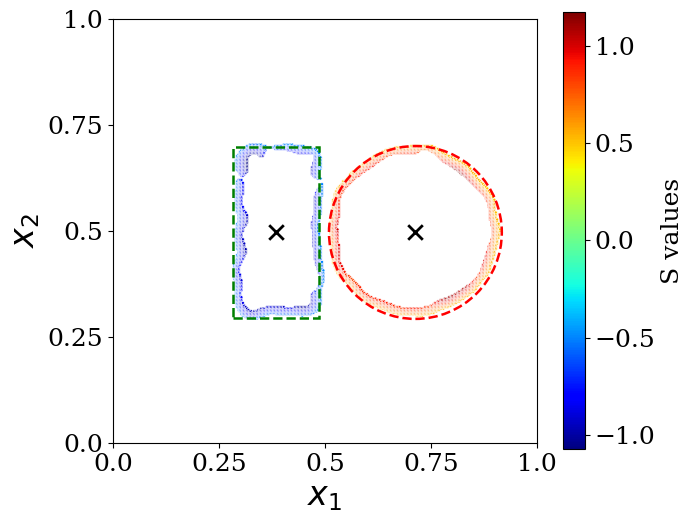

(i=0, j=1) para_abs=2.5, para_grad=3.0, c_eps=5.681, mini_samples=20
DBSCAN eps = 0.018935 (5.680635 * h, h = 0.003333)
Number of detected clusters: 2
  CV of S_num: 0.197
Cluster 0: AR=1.97
  Res_Rect=0.048636 vs Res_Ellip=0.143738
  center=(0.3854, 0.5050)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.202
Cluster 1: AR=1.01
  Res_Rect=0.095733 vs Res_Ellip=0.024693
  center=(0.7151, 0.4980)
  -> Decision: Circle (Sigmoid)


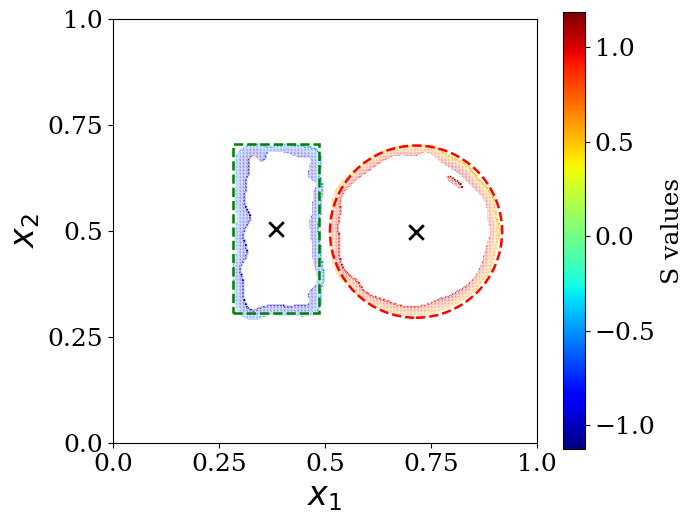

(i=0, j=2) para_abs=2.5, para_grad=4.0, c_eps=4.645, mini_samples=23
DBSCAN eps = 0.015482 (4.644508 * h, h = 0.003333)
Number of detected clusters: 3
Number of retained clusters: 2
  CV of S_num: 0.206
Cluster 0: AR=1.97
  Res_Rect=0.043695 vs Res_Ellip=0.141210
  center=(0.3874, 0.5089)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.208
Cluster 1: AR=1.01
  Res_Rect=0.094868 vs Res_Ellip=0.024594
  center=(0.7161, 0.5014)
  -> Decision: Circle (Sigmoid)


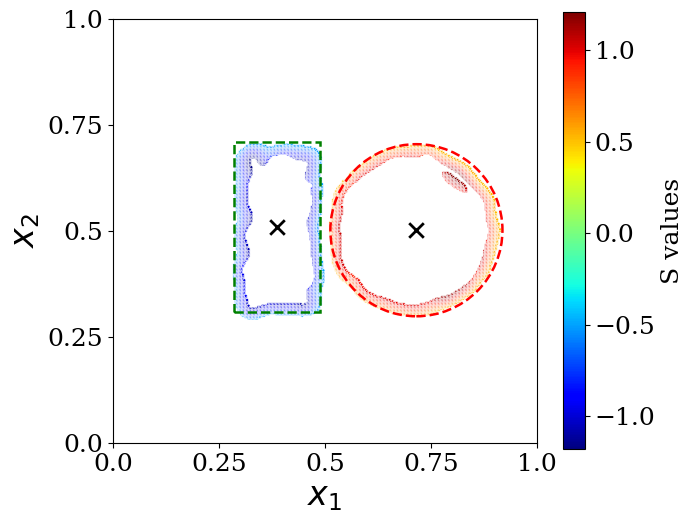

(i=0, j=3) para_abs=2.5, para_grad=5.0, c_eps=3.973, mini_samples=23
DBSCAN eps = 0.013243 (3.972855 * h, h = 0.003333)
Number of detected clusters: 5
Number of retained clusters: 2
  CV of S_num: 0.210
Cluster 0: AR=1.97
  Res_Rect=0.041998 vs Res_Ellip=0.140573
  center=(0.3885, 0.5107)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.210
Cluster 1: AR=1.00
  Res_Rect=0.097373 vs Res_Ellip=0.037183
  center=(0.7196, 0.4977)
  -> Decision: Circle (Sigmoid)


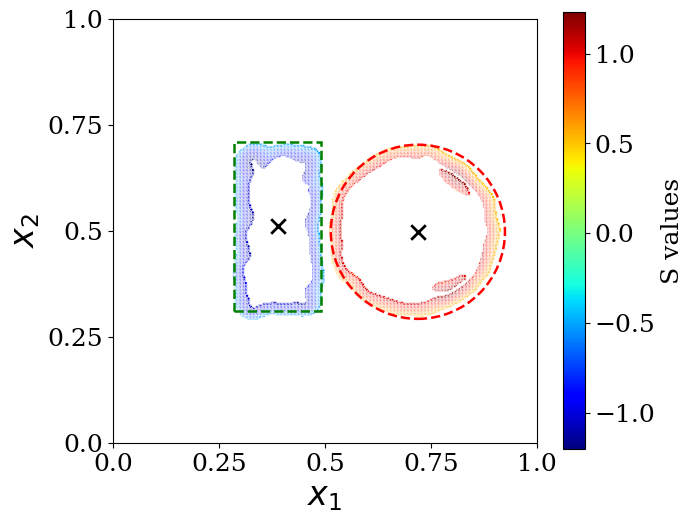

(i=1, j=0) para_abs=3.0, para_grad=2.5, c_eps=5.681, mini_samples=18
DBSCAN eps = 0.018935 (5.680635 * h, h = 0.003333)
Number of detected clusters: 2
  CV of S_num: 0.230
Cluster 0: AR=1.94
  Res_Rect=0.110671 vs Res_Ellip=0.124436
  center=(0.3856, 0.4992)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.238
Cluster 1: AR=1.02
  Res_Rect=0.095062 vs Res_Ellip=0.026842
  center=(0.7149, 0.4971)
  -> Decision: Circle (Sigmoid)


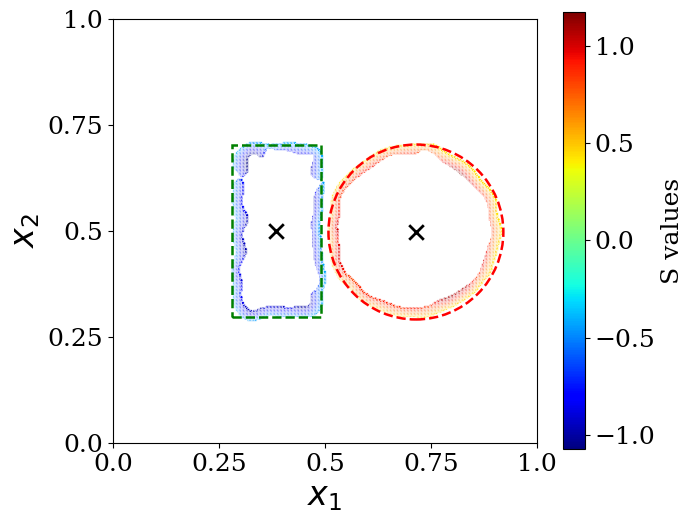

(i=1, j=1) para_abs=3.0, para_grad=3.0, c_eps=5.000, mini_samples=20
DBSCAN eps = 0.016667 (5.000000 * h, h = 0.003333)
Number of detected clusters: 3
Number of retained clusters: 2
  CV of S_num: 0.242
Cluster 0: AR=1.94
  Res_Rect=0.047597 vs Res_Ellip=0.142630
  center=(0.3854, 0.5068)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.243
Cluster 1: AR=1.02
  Res_Rect=0.094995 vs Res_Ellip=0.026702
  center=(0.7148, 0.4972)
  -> Decision: Circle (Sigmoid)


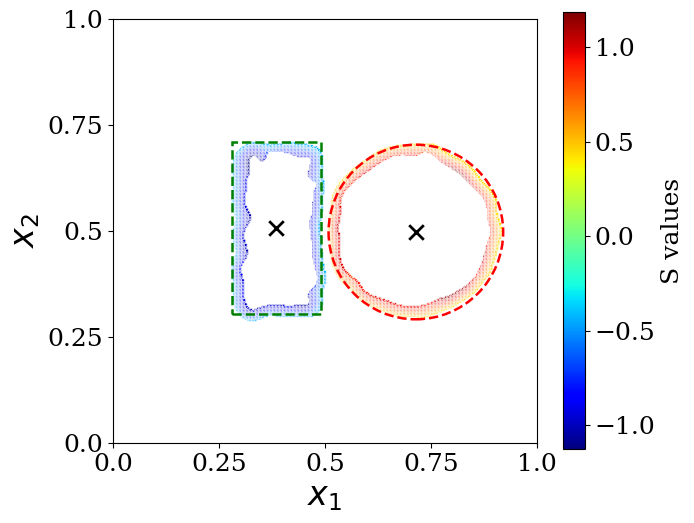

(i=1, j=2) para_abs=3.0, para_grad=4.0, c_eps=4.088, mini_samples=23
DBSCAN eps = 0.013627 (4.088019 * h, h = 0.003333)
Number of detected clusters: 3
Number of retained clusters: 2
  CV of S_num: 0.250
Cluster 0: AR=1.94
  Res_Rect=0.043264 vs Res_Ellip=0.141065
  center=(0.3871, 0.5099)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.251
Cluster 1: AR=1.02
  Res_Rect=0.094092 vs Res_Ellip=0.026825
  center=(0.7167, 0.5016)
  -> Decision: Circle (Sigmoid)


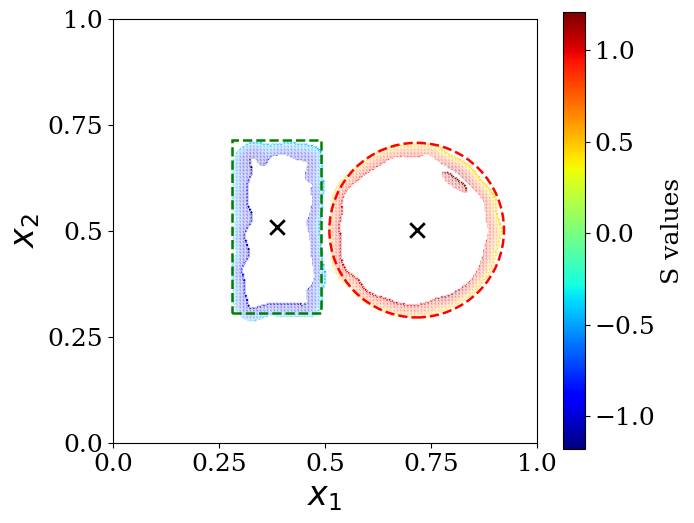

(i=1, j=3) para_abs=3.0, para_grad=5.0, c_eps=3.497, mini_samples=23
DBSCAN eps = 0.011656 (3.496841 * h, h = 0.003333)
Number of detected clusters: 7
Number of retained clusters: 2
  CV of S_num: 0.253
Cluster 0: AR=1.92
  Res_Rect=0.041303 vs Res_Ellip=0.143464
  center=(0.3881, 0.5114)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.250
Cluster 1: AR=1.01
  Res_Rect=0.091972 vs Res_Ellip=0.027263
  center=(0.7130, 0.4976)
  -> Decision: Circle (Sigmoid)


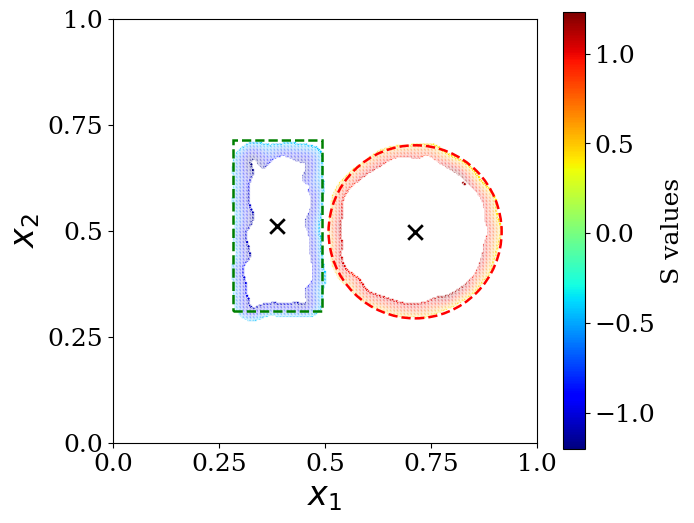

(i=2, j=0) para_abs=4.0, para_grad=2.5, c_eps=4.645, mini_samples=18
DBSCAN eps = 0.015482 (4.644508 * h, h = 0.003333)
Number of detected clusters: 2
  CV of S_num: 0.296
Cluster 0: AR=1.89
  Res_Rect=0.124239 vs Res_Ellip=0.124829
  center=(0.3866, 0.4976)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.303
Cluster 1: AR=1.02
  Res_Rect=0.094308 vs Res_Ellip=0.028213
  center=(0.7158, 0.4975)
  -> Decision: Circle (Sigmoid)


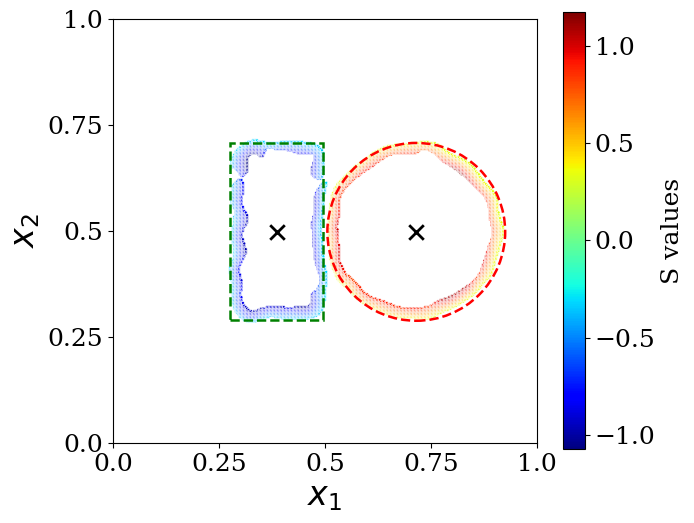

(i=2, j=1) para_abs=4.0, para_grad=3.0, c_eps=4.088, mini_samples=20
DBSCAN eps = 0.013627 (4.088019 * h, h = 0.003333)
Number of detected clusters: 3
Number of retained clusters: 2
  CV of S_num: 0.309
Cluster 0: AR=1.89
  Res_Rect=0.043702 vs Res_Ellip=0.137821
  center=(0.3854, 0.5063)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.307
Cluster 1: AR=1.02
  Res_Rect=0.094238 vs Res_Ellip=0.028029
  center=(0.7156, 0.4975)
  -> Decision: Circle (Sigmoid)


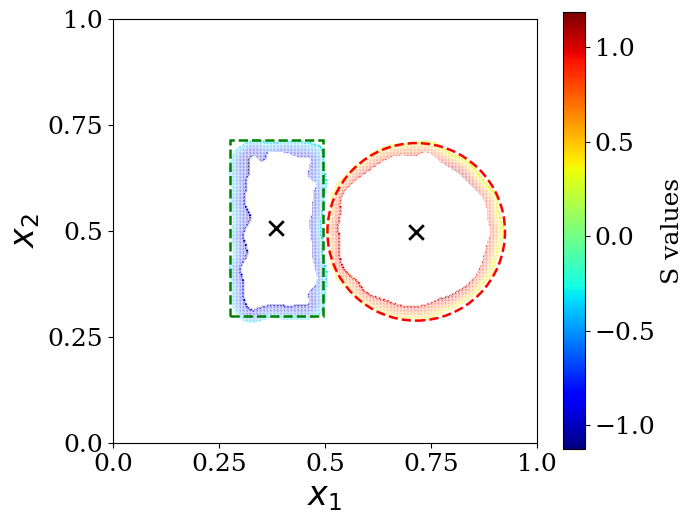

(i=2, j=2) para_abs=4.0, para_grad=4.0, c_eps=3.342, mini_samples=23
DBSCAN eps = 0.011141 (3.342380 * h, h = 0.003333)
Number of detected clusters: 4
Number of retained clusters: 2
  CV of S_num: 0.315
Cluster 0: AR=1.88
  Res_Rect=0.041176 vs Res_Ellip=0.139978
  center=(0.3869, 0.5090)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.311
Cluster 1: AR=1.02
  Res_Rect=0.093549 vs Res_Ellip=0.026481
  center=(0.7145, 0.4979)
  -> Decision: Circle (Sigmoid)


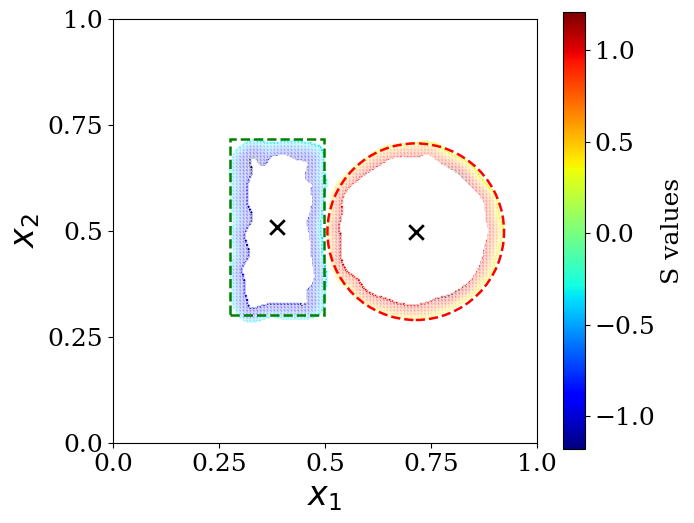

(i=2, j=3) para_abs=4.0, para_grad=5.0, c_eps=3.000, mini_samples=23
DBSCAN eps = 0.010000 (3.000000 * h, h = 0.003333)
Number of detected clusters: 5
Number of retained clusters: 2
  CV of S_num: 0.316
Cluster 0: AR=1.88
  Res_Rect=0.040183 vs Res_Ellip=0.139805
  center=(0.3878, 0.5103)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.312
Cluster 1: AR=1.02
  Res_Rect=0.093387 vs Res_Ellip=0.026184
  center=(0.7138, 0.4977)
  -> Decision: Circle (Sigmoid)


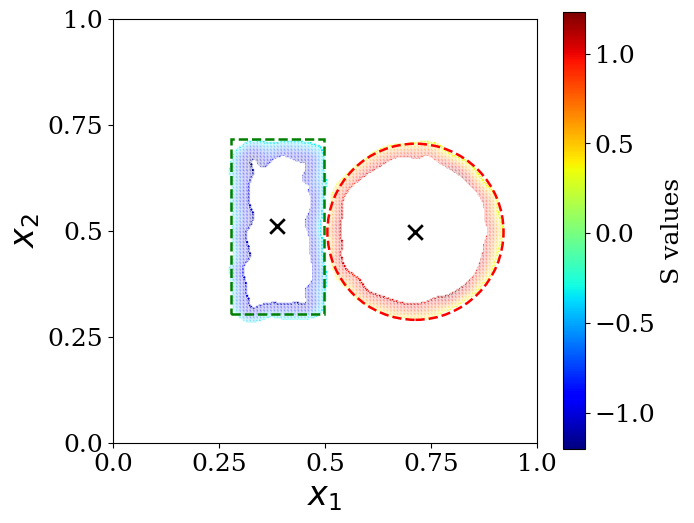

(i=3, j=0) para_abs=5.0, para_grad=2.5, c_eps=3.973, mini_samples=18
DBSCAN eps = 0.013243 (3.972855 * h, h = 0.003333)
Number of detected clusters: 2
  CV of S_num: 0.340
Cluster 0: AR=1.88
  Res_Rect=0.126840 vs Res_Ellip=0.127502
  center=(0.3869, 0.4972)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.351
Cluster 1: AR=1.02
  Res_Rect=0.096415 vs Res_Ellip=0.026209
  center=(0.7161, 0.4972)
  -> Decision: Circle (Sigmoid)


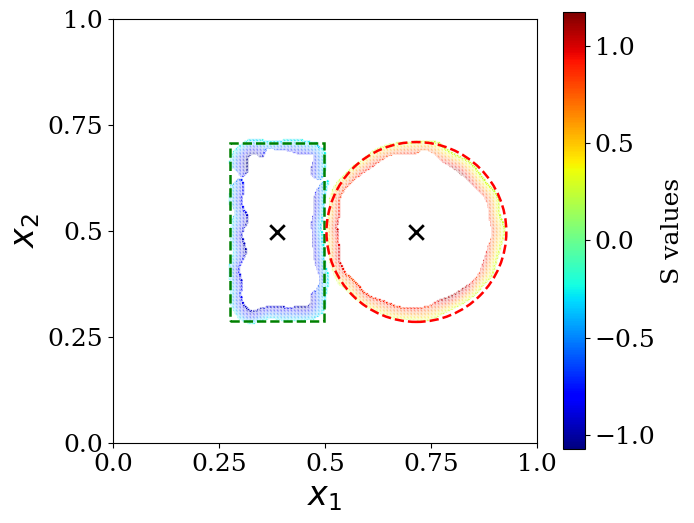

(i=3, j=1) para_abs=5.0, para_grad=3.0, c_eps=3.497, mini_samples=20
DBSCAN eps = 0.011656 (3.496841 * h, h = 0.003333)
Number of detected clusters: 3
Number of retained clusters: 2
  CV of S_num: 0.354
Cluster 0: AR=1.85
  Res_Rect=0.043445 vs Res_Ellip=0.137451
  center=(0.3854, 0.5059)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.355
Cluster 1: AR=1.02
  Res_Rect=0.096377 vs Res_Ellip=0.026168
  center=(0.7159, 0.4971)
  -> Decision: Circle (Sigmoid)


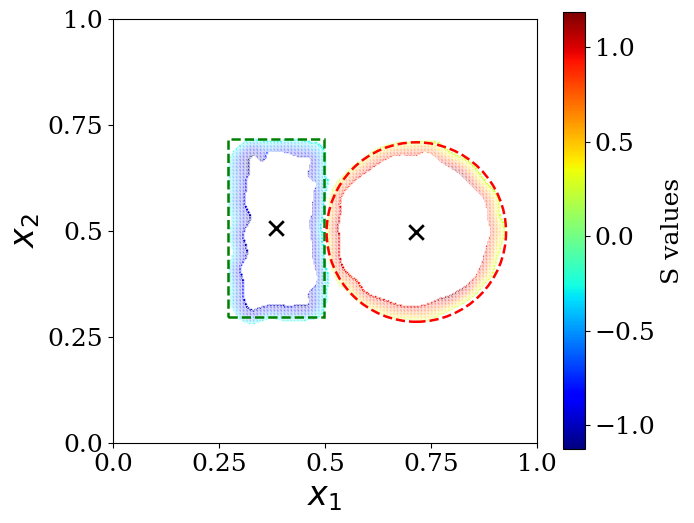

(i=3, j=2) para_abs=5.0, para_grad=4.0, c_eps=3.000, mini_samples=23
DBSCAN eps = 0.010000 (3.000000 * h, h = 0.003333)
Number of detected clusters: 4
Number of retained clusters: 2
  CV of S_num: 0.360
Cluster 0: AR=1.85
  Res_Rect=0.042797 vs Res_Ellip=0.137106
  center=(0.3869, 0.5087)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.357
Cluster 1: AR=1.02
  Res_Rect=0.093902 vs Res_Ellip=0.027276
  center=(0.7148, 0.4975)
  -> Decision: Circle (Sigmoid)


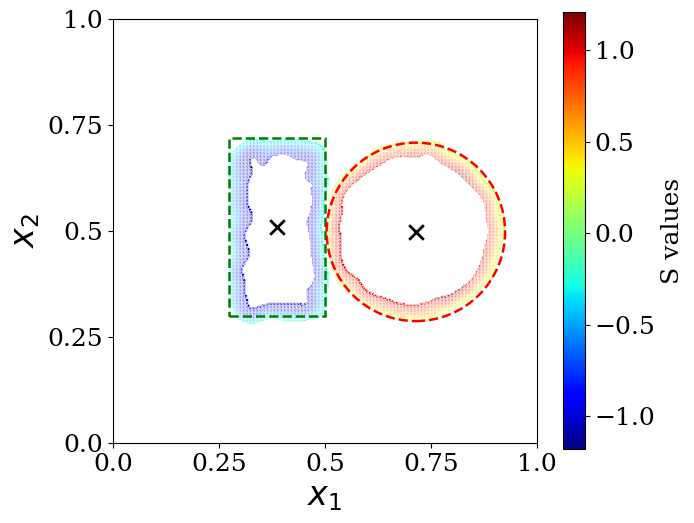

(i=3, j=3) para_abs=5.0, para_grad=5.0, c_eps=3.000, mini_samples=23
DBSCAN eps = 0.010000 (3.000000 * h, h = 0.003333)
Number of detected clusters: 5
Number of retained clusters: 2
  CV of S_num: 0.360
Cluster 0: AR=1.85
  Res_Rect=0.042391 vs Res_Ellip=0.136931
  center=(0.3877, 0.5099)
  -> Decision: Rectangle (Sigmoid)
  CV of S_num: 0.357
Cluster 1: AR=1.03
  Res_Rect=0.091491 vs Res_Ellip=0.031548
  center=(0.7142, 0.4973)
  -> Decision: Circle (Sigmoid)


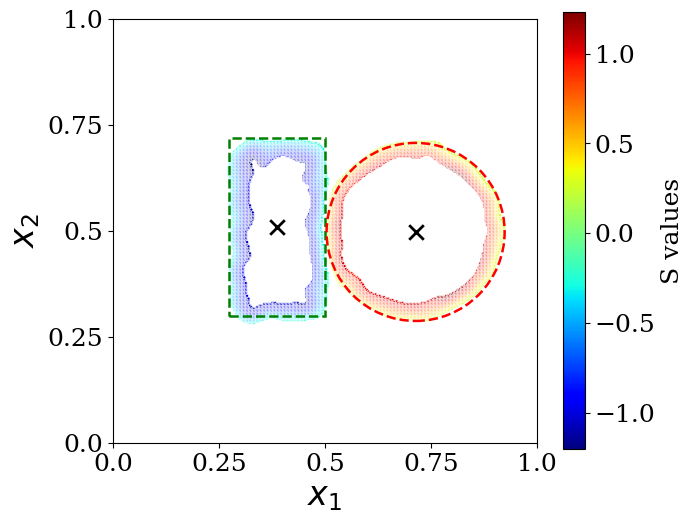

In [ ]:
import bound_detect
reload(bound_detect)

x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)

para_abs=np.array([2.5,3,4,5])
para_grad=np.array([2.5,3,4,5])

# Parameter-centered DBSCAN schedule.
# Reference point: (para_abs, para_grad) = (3, 3), where c_eps=5 and mini_samples=20.
# Larger para_abs / para_grad means looser thresholding and more candidate Q points,
# so c_eps is decreased to avoid merging nearby components.
# mini_samples mainly follows para_grad: para_abs only gates amplitudes, and increasing
# mini_samples with para_abs can erode sparse rectangle boundary arcs.
para_abs_ref = 3.0
para_grad_ref = 3.0
c_eps_base = 5.0
mini_base = 20.0
c_eps_power = 1.4
mini_grad_power = 0.5
c_eps_min, c_eps_max = 3.0, 6.0
mini_min, mini_max = 10, 23

scale = np.sqrt((para_abs[:, None] / para_abs_ref) * (para_grad[None, :] / para_grad_ref))
c_eps_list = np.clip(c_eps_base / (scale ** c_eps_power), c_eps_min, c_eps_max)
mini_grad_scale = (para_grad[None, :] / para_grad_ref) ** mini_grad_power
mini_samples_list = np.rint(np.clip(mini_base * mini_grad_scale, mini_min, mini_max)).astype(int)
mini_samples_list = np.repeat(mini_samples_list, len(para_abs), axis=0)
mini_samples_list[0, 0] = 10

results={}
used_c_eps={}
used_mini_samples={}
for i in range(len(c_eps_list)):
    for j in range(len(c_eps_list)):
        c_eps=c_eps_list[i][j]
        mini_samples33=mini_samples_list[i][j]
        para_abs33=para_abs[i]
        para_grad33=para_grad[j]
        print(f"(i={i}, j={j}) para_abs={para_abs33}, para_grad={para_grad33}, c_eps={c_eps:.3f}, mini_samples={mini_samples33}")
        results[(i,j)]=bound_detect.detect_shape(
            g_S, X.T, Y.T,
            tau_x_min, tau_x_max, tau_y_min, tau_y_max,
            para_abs33, para_grad33, c_eps, mini_samples33,
            S_num_store[-1],
            output_directory="./results_ada/noise=1%_grad",
            output_filename="plot_{}_{}.png".format(i,j),
            eps_mode="grid_scaled",
            min_cluster_size=200,
            min_relative_abs_s=0.2,
            min_relative_grad=0.25,
            keep_top_k=None,
        )
        used_c_eps[(i,j)] = c_eps
        used_mini_samples[(i,j)] = mini_samples33


In [ ]:
results

{(0,
  0): [{'cluster_id': 0,
   'shape': 'Rectangle',
   'params': {'center': array([0.38488427, 0.49699703]),
    'W': np.float64(0.2033333333333333),
    'H': np.float64(0.4033333333333334)},
   'profile': 'Sigmoid',
   'boundary_points': array([[0.32025667, 0.29337333],
          [0.32025667, 0.29398333],
          [0.32025667, 0.29459333],
          ...,
          [0.32208667, 0.29337333],
          [0.32147667, 0.29337333],
          [0.32086667, 0.29337333]])}, {'cluster_id': 1,
   'shape': 'Circle',
   'params': {'center': array([0.71368239, 0.49603249]),
    'radius': 0.20389468578194217},
   'profile': 'Sigmoid',
   'boundary_points': array([[0.71693333, 0.3002    ],
          [0.71693333, 0.3008    ],
          [0.71693333, 0.3014    ],
          ...,
          [0.71873333, 0.3002    ],
          [0.71813333, 0.3002    ],
          [0.71753333, 0.3002    ]])}],
 (0,
  1): [{'cluster_id': 0,
   'shape': 'Rectangle',
   'params': {'center': array([0.38542018, 0.50500469]),
   

In [ ]:
Qx,Qy=150,150
M_ellip=800
M_rec=800
lamb_regu=np.logspace(-4,0,9,endpoint=True)
reload(inverse_solver)
reload(error_general_2d)
reload(net_2d)
reload(matrix_assemble)

S_l2={}
lambda_candidates={}
window_results_all={}
selected_idx={}
selected_lambda={}
selected_w={}

for i in range(len(para_abs)):
    for j in range(len(para_grad)):
        current_results = results[(i,j)]
        rect_entry = next((item for item in current_results if item.get('shape') == 'Rectangle'), None)
        ellip_entry = next((item for item in current_results if item.get('shape') == 'Ellipsoid'), None)

        if rect_entry is None or ellip_entry is None:
            print(f"(i={i}, j={j}) missing Rectangle/Ellipsoid detection; skip this pair.")
            S_l2[(i,j)] = np.nan
            lambda_candidates[(i,j)] = []
            window_results_all[(i,j)] = []
            selected_idx[(i,j)] = None
            selected_lambda[(i,j)] = np.nan
            selected_w[(i,j)] = None
            continue

        center1 = np.asarray(rect_entry['params']['center'])
        width = rect_entry['params']['W']
        height = rect_entry['params']['H']
        center2 = np.asarray(ellip_entry['params']['center'])
        a_ellip = float(ellip_entry['params'].get('a', ellip_entry['params'].get('radius')))
        b_ellip = float(ellip_entry['params'].get('b', ellip_entry['params'].get('radius')))
        r_equiv = float(ellip_entry['params'].get('radius', max(a_ellip, b_ellip)))

        theta_min, theta_max = -1e-12, 1e-12
        K_old_min = 1000
        K_old_max = 20000
        # Use the paper's 2D nondimensional K mapping:
        #   K_ellip = (a*b) * K_old, with semi-axes a and b.
        #   K_rec = sqrt((width/2)*(height/2)) * K_old = 0.5*sqrt(width*height) * K_old.
        ellip_char = a_ellip * b_ellip
        K_ellip_min = ellip_char * K_old_min
        K_ellip_max = ellip_char * K_old_max
        rect_char = 0.5 * np.sqrt(width * height)
        K_rec_min = rect_char * K_old_min
        K_rec_max = rect_char * K_old_max
        min_rec1,max_rec1,min_rec2,max_rec2=-center1[0]*(1+0.05),-center1[0]*(1-0.05),-center1[1]*(1+0.05),-center1[1]*(1-0.05)
        min_ellip1,max_ellip1=min(center2[0]*(1-0.05), center2[0]*(1+0.05)),max(center2[0]*(1-0.05), center2[0]*(1+0.05))
        min_ellip2,max_ellip2=min(center2[1]*(1-0.05), center2[1]*(1+0.05)),max(center2[1]*(1-0.05), center2[1]*(1+0.05))
        axis_a_min,axis_a_max=a_ellip*(1-0.1),a_ellip*(1+0.05)
        axis_b_min,axis_b_max=b_ellip*(1-0.1),b_ellip*(1+0.05)
        width_min,width_max=width*(1-0.1),width*(1+0.05)
        height_min,height_max=height*(1-0.1),height*(1+0.05)

        models0=models
        models1=net_2d.pre_define(Nx,Ny,M_ellip,R_m,'sigmoid',tau_x_min,tau_x_max,tau_y_min,tau_y_max,theta_min,theta_max,min_ellip1,max_ellip1,min_ellip2,max_ellip2,axis_a_min,axis_a_max,axis_b_min,axis_b_max,[],[],[],[],K_ellip_min, K_ellip_max, 'ellipsoid',device)
        models2=net_2d.pre_define(Nx,Ny,M_rec,R_m,'sigmoid',tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],min_rec1,max_rec1,min_rec2,max_rec2,width_min,width_max,height_min,height_max,[],[],[],[],K_rec_min, K_rec_max, 'rec',device)
        af='mix'

        sum_mat,all_g_p1,all_g_n,cells_copy1 = matrix_assemble.mat_assemble2(
            cells_store_last,models0,models1,models2,'mix','ellipsoid','rec',kk,0,points_b,device,cupy_device
        )
        res,reg_norm,w_store = inverse_solver.L_curve(sum_mat,F_05,[],[],[],lamb_regu,'linear',device,cupy_device)
        window_idx, window_lambda, window_w, curvature = inverse_solver.lambda_window_by_curvature(
            lamb_regu, res, reg_norm, radius=1, w_store=w_store
        )

        lambda_candidates[(i,j)] = [float(val**2) for val in window_lambda]
        print(f"(i={i}, j={j}) candidate idx: {window_idx}")
        print(f"(i={i}, j={j}) candidate lambda: {lambda_candidates[(i,j)]}")

        window_results = []
        for local_i, cand_idx in enumerate(window_idx):
            cand_lamb = window_lambda[local_i]**2
            cand_w = window_w[:, local_i]
            result_tuple = error_general_2d.test(
                models0,models1,models2,[],Qx,Qy,cand_w,'mix','ellipsoid','rec',
                False,False,tau_x_min,tau_x_max,tau_y_min,tau_y_max,
                x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,0,device
            )
            window_results.append({
                'idx': int(cand_idx),
                'lambda': float(cand_lamb),
                'w': cand_w,
                'result': result_tuple,
            })
            print(
                f"(i={i}, j={j}) candidate idx={int(cand_idx)}, lamb={cand_lamb}, "
                f"S_l_inf={result_tuple[2]}, S_l_2={result_tuple[3]}"
            )

        window_results_all[(i,j)] = window_results
        pick = 0
        picked = window_results[pick]
        selected_idx[(i,j)] = picked['idx']
        selected_lambda[(i,j)] = picked['lambda']
        selected_w[(i,j)] = picked['w']
        S_l2[(i,j)] = picked['result'][3]
        print(f"(i={i}, j={j}) picked idx: {selected_idx[(i,j)]}")
        print(f"(i={i}, j={j}) picked lambda: {selected_lambda[(i,j)]}")

        del models1, models2, sum_mat, all_g_p1, all_g_n, cells_copy1, res, reg_norm, w_store, window_results
        if device.type == 'cuda':
            torch.cuda.empty_cache()



In [ ]:
S_l2

{(0, 0): 0.14941678684129575,
 (0, 1): 0.14857131251362835,
 (0, 2): 0.1507428490202225,
 (0, 3): 0.1534411059351608,
 (1, 0): 0.1518413748435151,
 (1, 1): 0.1549437641488738,
 (1, 2): 0.15289477336565546,
 (1, 3): 0.1566982854406784,
 (2, 0): 0.1513276905903118,
 (2, 1): 0.1562615120130949,
 (2, 2): 0.15721606698949803,
 (2, 3): 0.1555275594050576,
 (3, 0): 0.15078991537592543,
 (3, 1): 0.16046353305564268,
 (3, 2): 0.15699316572560357,
 (3, 3): 0.15023770776599757}

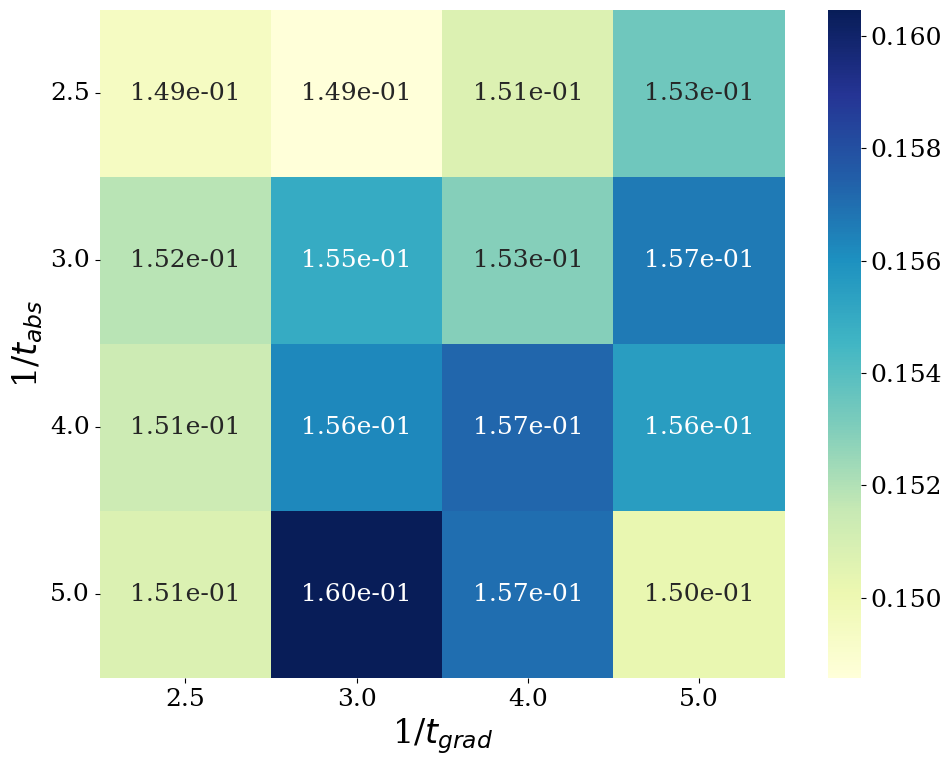

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
plt.rcParams['font.size'] = 18

# Construct a 2D matrix
data = np.array([
    [S_l2[(i, j)] for j in range(len(para_grad))]
    for i in range(len(para_abs))
])

ax = sns.heatmap(
    data,
    annot=True,
    fmt='.2e',
    cmap='YlGnBu',
    xticklabels=para_grad,
    yticklabels=para_abs
)
# Colorbar font size
ax.collections[0].colorbar.ax.tick_params(labelsize=18)

plt.xlabel(r'1/$t_{grad}$', fontsize=24)
plt.ylabel(r'1/$t_{abs}$', fontsize=24)

plt.tick_params(axis='both', which='major', labelsize=18)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
# Save
plt.savefig("./Noise/noise=5%/L2_sensitivity_analysis.pdf", dpi=300)
plt.show()
